<a href="https://colab.research.google.com/github/beena24/Research_works/blob/main/ILD_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load the data
data = pd.read_csv('/content/drive/MyDrive/vitfeat.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Train a Random Forest classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

class-label
1    569
2    441
3    231
4    142
0    108
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       114
           1       0.87      0.83      0.85       113
           2       0.85      0.91      0.88       114
           3       0.94      0.93      0.93       114
           4       0.98      0.96      0.97       114

    accuracy                           0.93       569
   macro avg       0.93      0.93      0.93       569
weighted avg       0.93      0.93      0.93       569

[[113   0   1   0   0]
 [  1  94  11   6   1]
 [  0   8 104   1   1]
 [  0   6   2 106   0]
 [  0   0   4   0 110]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the data
data = pd.read_csv('/content/drive/MyDrive/vitfeat.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Initialize classifiers for ensemble methods
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Voting Classifier
voting_clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb), ('xgb', xgb_model)], voting='soft')
voting_clf.fit(X_train, y_train)

# Stacking Classifier with Logistic Regression as a meta-classifier
stacking_clf = StackingClassifier(estimators=[('rf', rf), ('gb', gb), ('xgb', xgb_model)], final_estimator=LogisticRegression(), cv=5)
stacking_clf.fit(X_train, y_train)



# Evaluate the models
print("Voting Classifier Results:")
y_pred_voting = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred_voting))
print(confusion_matrix(y_test, y_pred_voting))

print("Stacking Classifier Results:")
y_pred_stacking = stacking_clf.predict(X_test)
print(classification_report(y_test, y_pred_stacking))
print(confusion_matrix(y_test, y_pred_stacking))



class-label
1    569
2    441
3    231
4    142
0    108
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:29:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:52:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [06:17:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [06:19:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [06:21:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Voting Classifier Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       0.86      0.87      0.86       113
           2       0.90      0.89      0.90       114
           3       0.94      0.95      0.94       114
           4       0.98      0.97      0.98       114

    accuracy                           0.94       569
   macro avg       0.94      0.94      0.94       569
weighted avg       0.94      0.94      0.94       569

[[114   0   0   0   0]
 [  0  98  10   4   1]
 [  0   8 102   3   1]
 [  0   6   0 108   0]
 [  0   2   1   0 111]]
Stacking Classifier Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       0.87      0.87      0.87       113
           2       0.89      0.91      0.90       114
           3       0.96      0.94      0.95       114
           4       0.98      0.97      0.98       114

    accuracy 

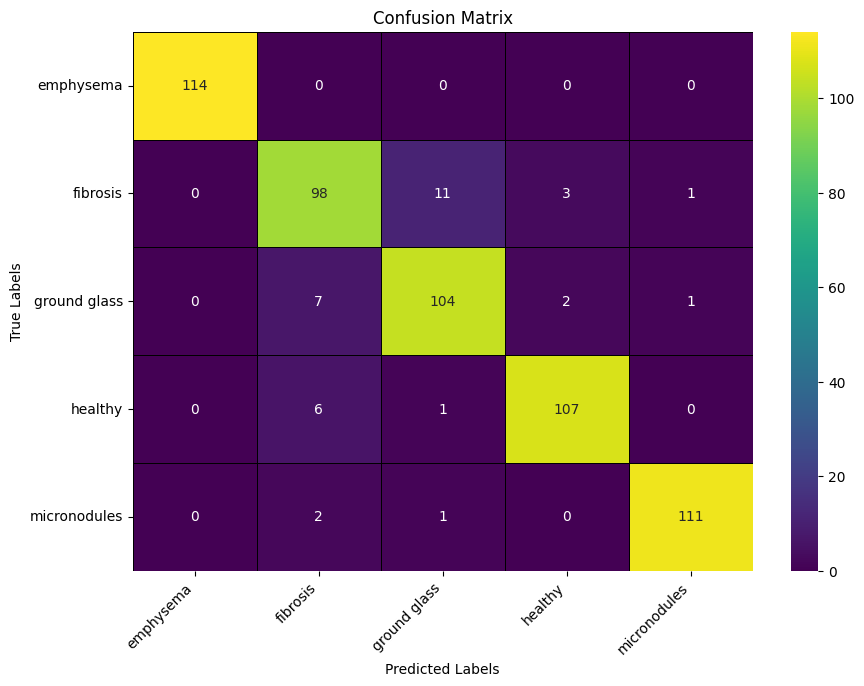

In [ ]:
# Define the confusion matrix
cm = np.array([[114,  0,  0,  0,  0],
               [  0, 98, 11,  3,  1],
               [  0,  7, 104,  2,  1],
               [  0,  6,  1, 107,  0],
               [  0,  2,  1,  0, 111]])

# Define class names corresponding to the labels
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']

# Plot the confusion matrix with class names
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black', cbar=True)

# Add labels, title, and set class names on the axes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the data
data = pd.read_csv('/content/drive/MyDrive/vitfeat.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Deep Learning Model (Simple MLP)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

print("Deep Learning Model Results:")
y_pred_dl = model.predict(X_test)
y_pred_dl = y_pred_dl.argmax(axis=1)
print(classification_report(y_test, y_pred_dl))
print(confusion_matrix(y_test, y_pred_dl))


class-label
1    569
2    441
3    231
4    142
0    108
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4108 - loss: 1.6961 - val_accuracy: 0.8158 - val_loss: 0.5631
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7592 - loss: 0.6545 - val_accuracy: 0.8640 - val_loss: 0.3799
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8356 - loss: 0.4370 - val_accuracy: 0.9035 - val_loss: 0.2815
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8964 - loss: 0.2873 - val_accuracy: 0.9101 - val_loss: 0.2516
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9221 - loss: 0.2315 - val_accuracy: 0.9123 - val_loss: 0.2467
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9269 - loss: 0.1920 - val_accuracy: 0.9276 - val_loss: 0.2013
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9575 - loss: 0.1335 - val_accuracy: 0.9364 - val_loss: 0.2254
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9609 - loss: 0.1113 - val_accuracy: 0.92

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

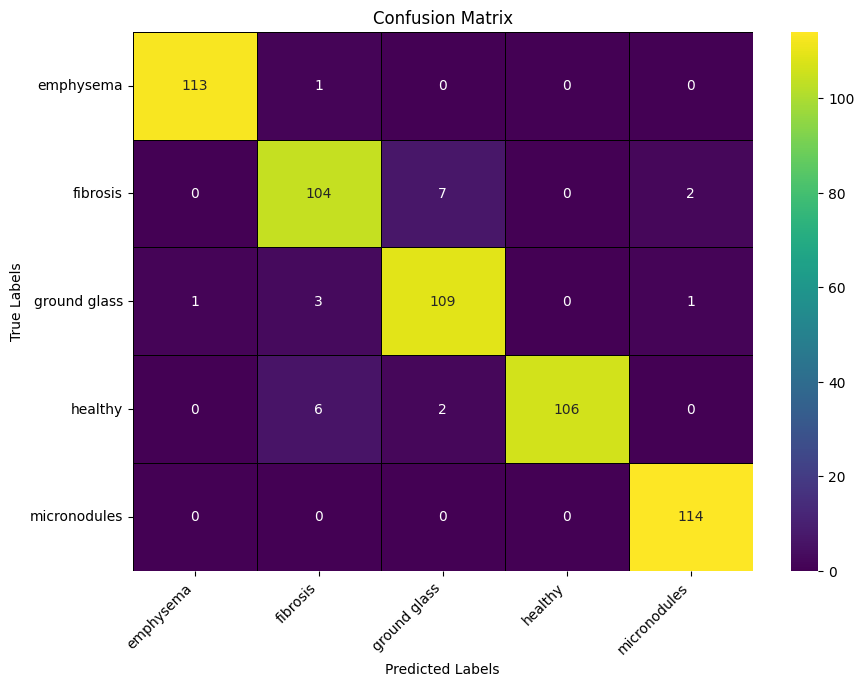

In [ ]:
# Define the confusion matrix
cm = np.array([[113,  1,  0,  0,  0],
               [  0, 104,  7,  0,  2],
               [  1,  3, 109,  0,  1],
               [  0,  6,  2, 106,  0],
               [  0,  0,  0,  0, 114]])

# Define class names corresponding to the labels
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']

# Plot the confusion matrix with class names
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black', cbar=True)

# Add labels, title, and set class names on the axes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import numpy as np

# Load the data
data = pd.read_csv('/content/drive/MyDrive/vitfeat.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print(data['class-label'].value_counts())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Train an XGBoost classifier
model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Iterate over classes and print top 10 contributing features
for class_index in range(shap_values.shape[2]):
    print(f"Top 10 contributing features for class {class_index}:")

    # Select SHAP values for the current class
    class_shap_values = shap_values[:,:,class_index]

    # Calculate mean absolute SHAP values for each feature
    mean_abs_shap_values = np.mean(np.abs(class_shap_values), axis=0)

    # Get feature names sorted by mean absolute SHAP value
    top_feature_indices = np.argsort(mean_abs_shap_values)[-10:][::-1]
    top_features = X.columns[top_feature_indices]

    for feature in top_features:
        print(f"- {feature}")
    print("\n")

# SHAP Force plot for a single prediction (for the first class)
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0,:,0], X_test[0], feature_names=X.columns)

class-label
1    569
2    441
3    231
4    142
0    108
Name: count, dtype: int64
class-label
1    569
2    441
3    231
4    142
0    108
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       114
           1       0.86      0.84      0.85       113
           2       0.88      0.86      0.87       114
           3       0.92      0.95      0.94       114
           4       0.97      0.99      0.98       114

    accuracy                           0.93       569
   macro avg       0.93      0.93      0.93       569
weighted avg       0.93      0.93      0.93       569

[[114   0   0   0   0]
 [  0  95  12   5   1]
 [  1  10  98   4   1]
 [  0   5   0 108   1]
 [  0   0   1   0 113]]
Top 10 contributing features for class 0:
- -7.91E-02.1
- -2.02E-02
- -4.21E-02
- 1.06E-01
- 8.56E-03
- -1.00E-01.7
- -4.34E-02
- -4.10E-01
- -1.70E-01
- -4.13E-01


Top 10 contributing features for class 1:
- 2.39E-01
- 1.22E-01

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


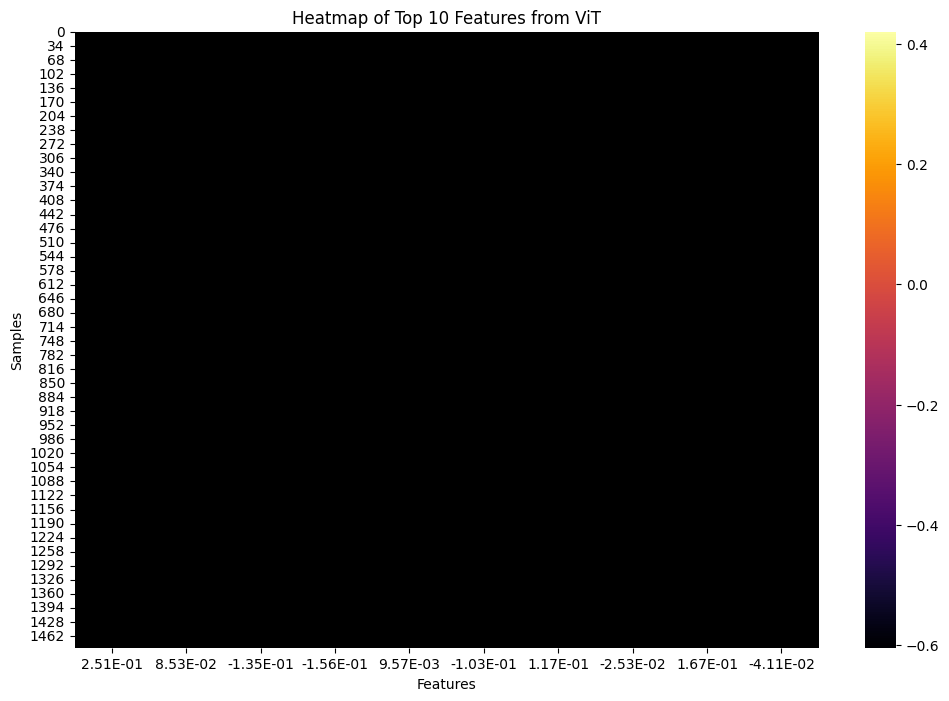

In [ ]:
# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

 #Select the top 10 features (assuming 'features' are columns and 'samples' are rows)
# If you want the top 10 features based on some criterion, you may need to modify this step
top_10_features = df.iloc[:, :10]  # Select first 10 columns as an example

# Define a custom color map for better visibility
from matplotlib.colors import LinearSegmentedColormap

# Plot the heatmap with a dark color map
plt.figure(figsize=(12, 8))
sns.heatmap(top_10_features, cmap='inferno', annot=False, linewidths=0.5, linecolor='black', cbar=True)

# Customize labels and title (if applicable)
plt.title('Heatmap of Top 10 Features from ViT')
plt.xlabel('Features')
plt.ylabel('Samples')  # Replace with 'Labels' if you set an index

plt.show()

In [ ]:
print(top_10_features.describe())


          2.51E-01     8.53E-02    -1.35E-01    -1.56E-01     9.57E-03  \
count  1491.000000  1491.000000  1491.000000  1491.000000  1491.000000   
mean      0.076347     0.053612    -0.130852    -0.024759     0.002314   
std       0.099664     0.099338     0.124527     0.089517     0.088931   
min      -0.272000    -0.210000    -0.458000    -0.351000    -0.286000   
25%       0.011650    -0.014900    -0.222000    -0.081750    -0.058800   
50%       0.083000     0.042600    -0.137000    -0.020600     0.002150   
75%       0.143000     0.110000    -0.047150     0.038250     0.066600   
max       0.375000     0.420000     0.325000     0.317000     0.258000   

         -1.03E-01     1.17E-01    -2.53E-02     1.67E-01    -4.11E-02  
count  1491.000000  1491.000000  1491.000000  1491.000000  1491.000000  
mean     -0.113679    -0.110018     0.081849     0.154657    -0.110121  
std       0.102647     0.140753     0.101069     0.097613     0.083770  
min      -0.444000    -0.604000    -0.261

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


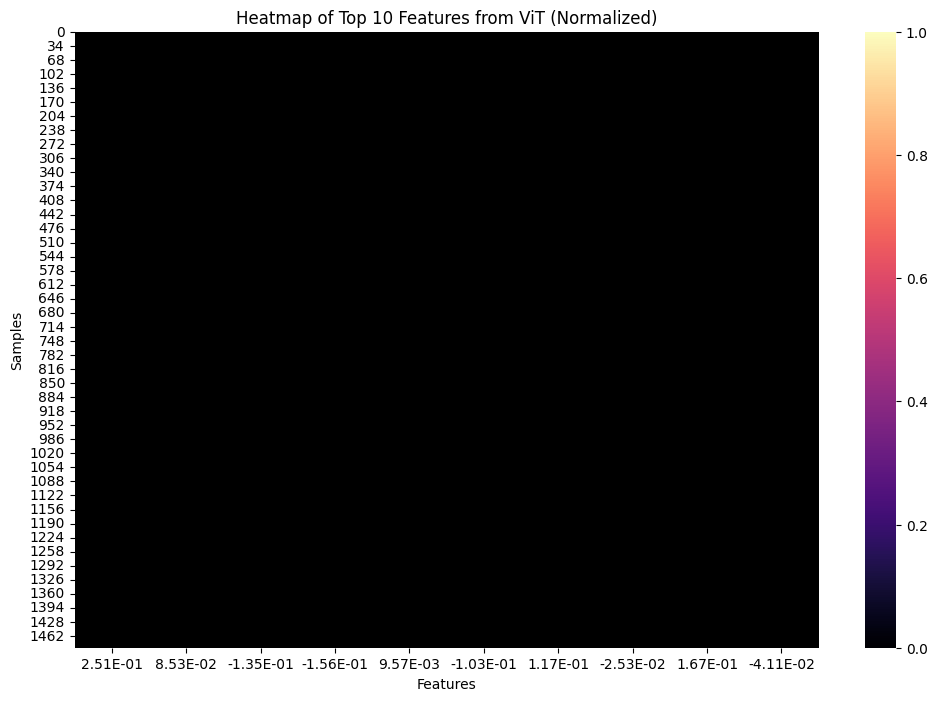

In [ ]:
# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features (assuming 'features' are columns and 'samples' are rows)
top_10_features = df.iloc[:, :10]  # Select first 10 columns as an example

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Plot the heatmap with a dark color map
plt.figure(figsize=(12, 8))
sns.heatmap(top_10_features_normalized, cmap='magma', annot=False, linewidths=0.5, linecolor='black', cbar=True)

# Customize labels and title
plt.title('Heatmap of Top 10 Features from ViT (Normalized)')
plt.xlabel('Features')
plt.ylabel('Samples')  # Replace with 'Labels' if you set an index

plt.show()


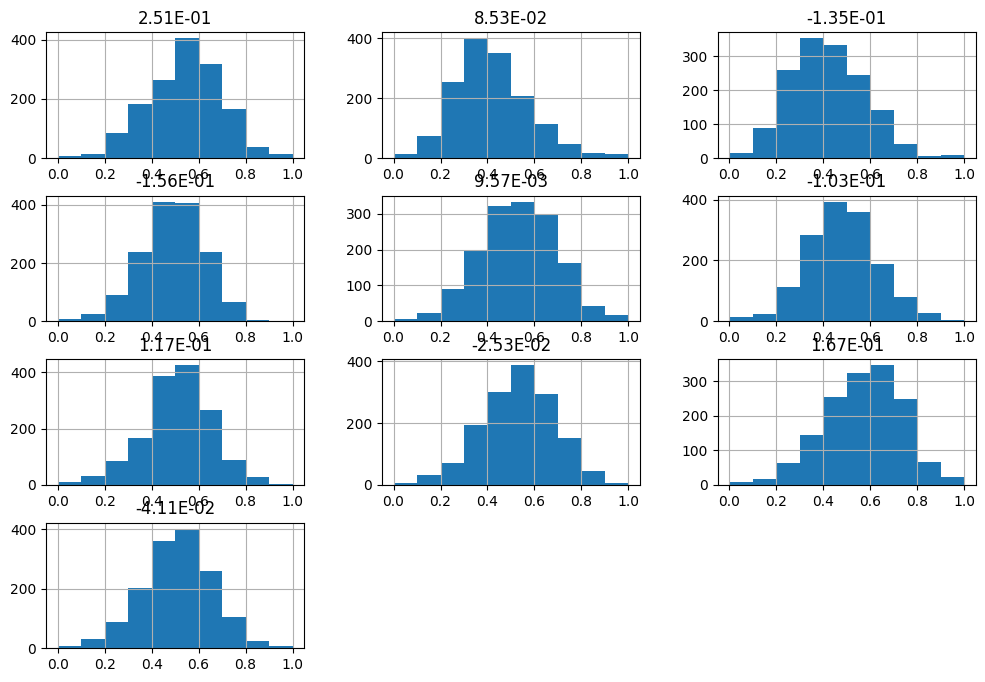

In [ ]:
top_10_features_normalized.hist(figsize=(12, 8))
plt.show()


In [ ]:
print(top_10_features_normalized.min().min())
print(top_10_features_normalized.max().max())


0.0
1.0000000000000002


In [ ]:
print(top_10_features_normalized.var())


2.51E-01     0.023729
8.53E-02     0.024863
-1.35E-01    0.025293
-1.56E-01    0.017958
9.57E-03     0.026724
-1.03E-01    0.022260
1.17E-01     0.021056
-2.53E-02    0.024478
1.67E-01     0.026292
-4.11E-02    0.022218
dtype: float64


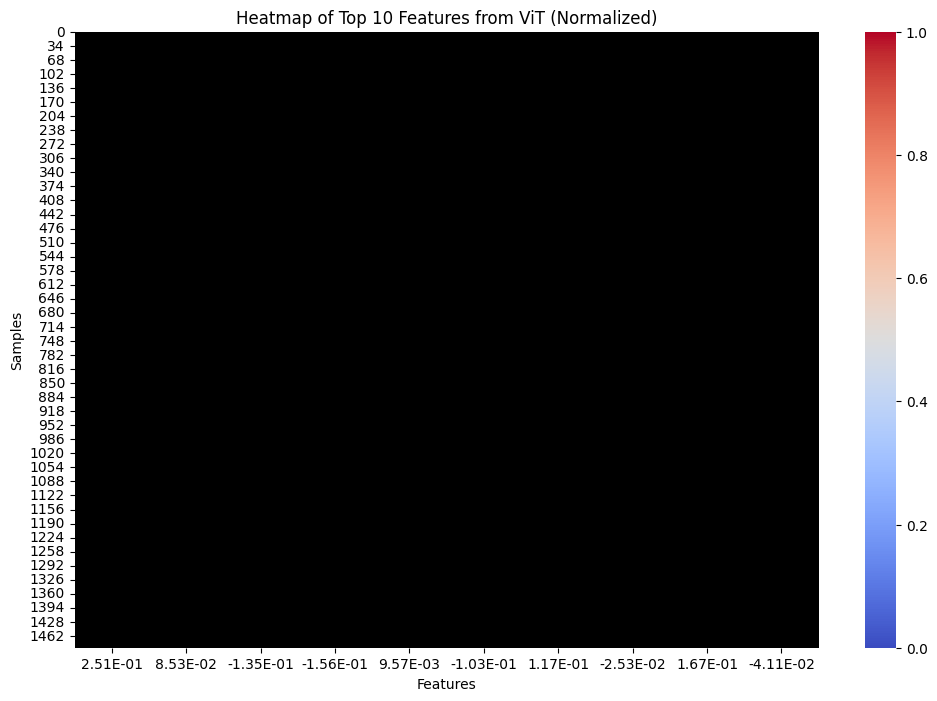

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(top_10_features_normalized, cmap='coolwarm', annot=False, linewidths=0.5, linecolor='black', cbar=True)
plt.title('Heatmap of Top 10 Features from ViT (Normalized)')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.show()


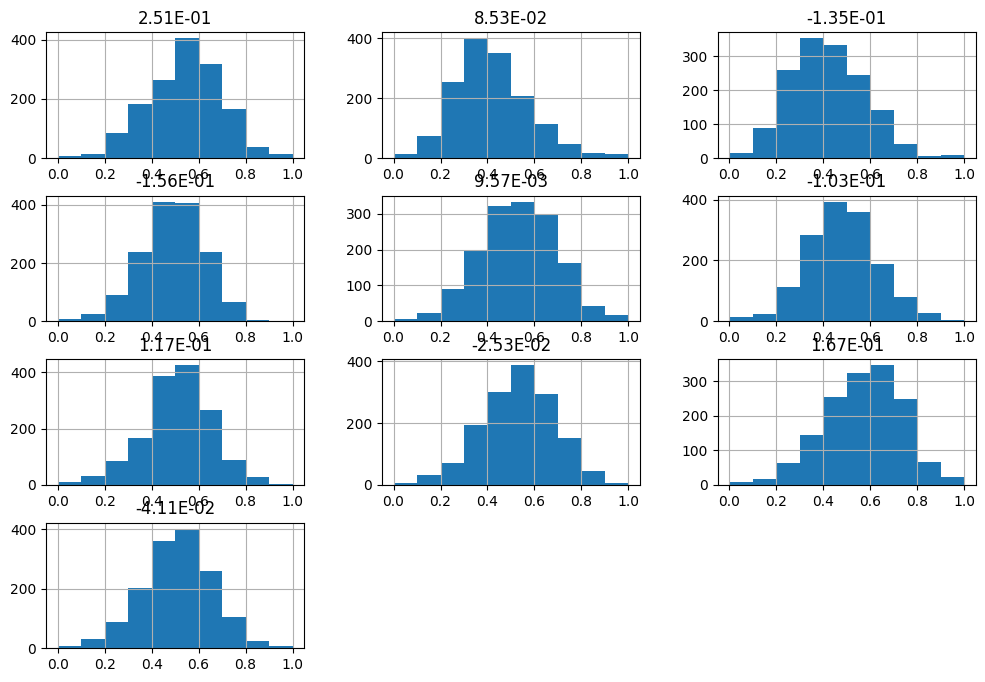

In [ ]:
top_10_features_normalized.hist(figsize=(12, 8))
plt.show()


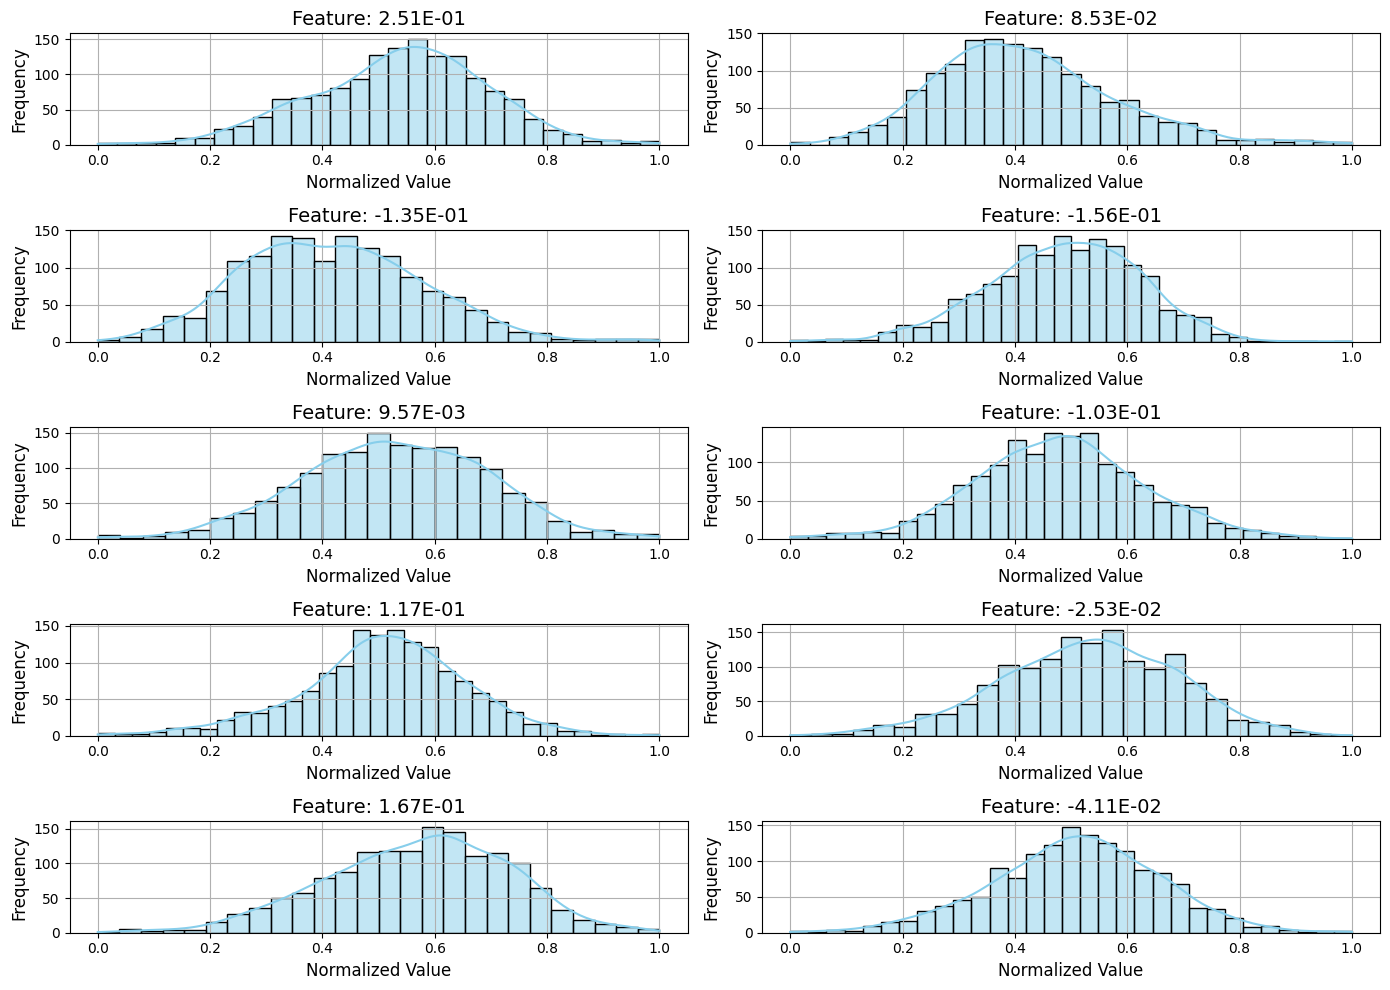

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features
top_10_features = df.iloc[:, :10]  # Adjust the selection if needed

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Plot histograms with improved aesthetics
plt.figure(figsize=(14, 10))

# Loop through each feature to create individual histograms
for i, column in enumerate(top_10_features_normalized.columns):
    plt.subplot(5, 2, i + 1)  # Adjust the grid size if you have more or fewer features
    sns.histplot(top_10_features_normalized[column], kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Feature: {column}', fontsize=14)
    plt.xlabel('Normalized Value', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable h

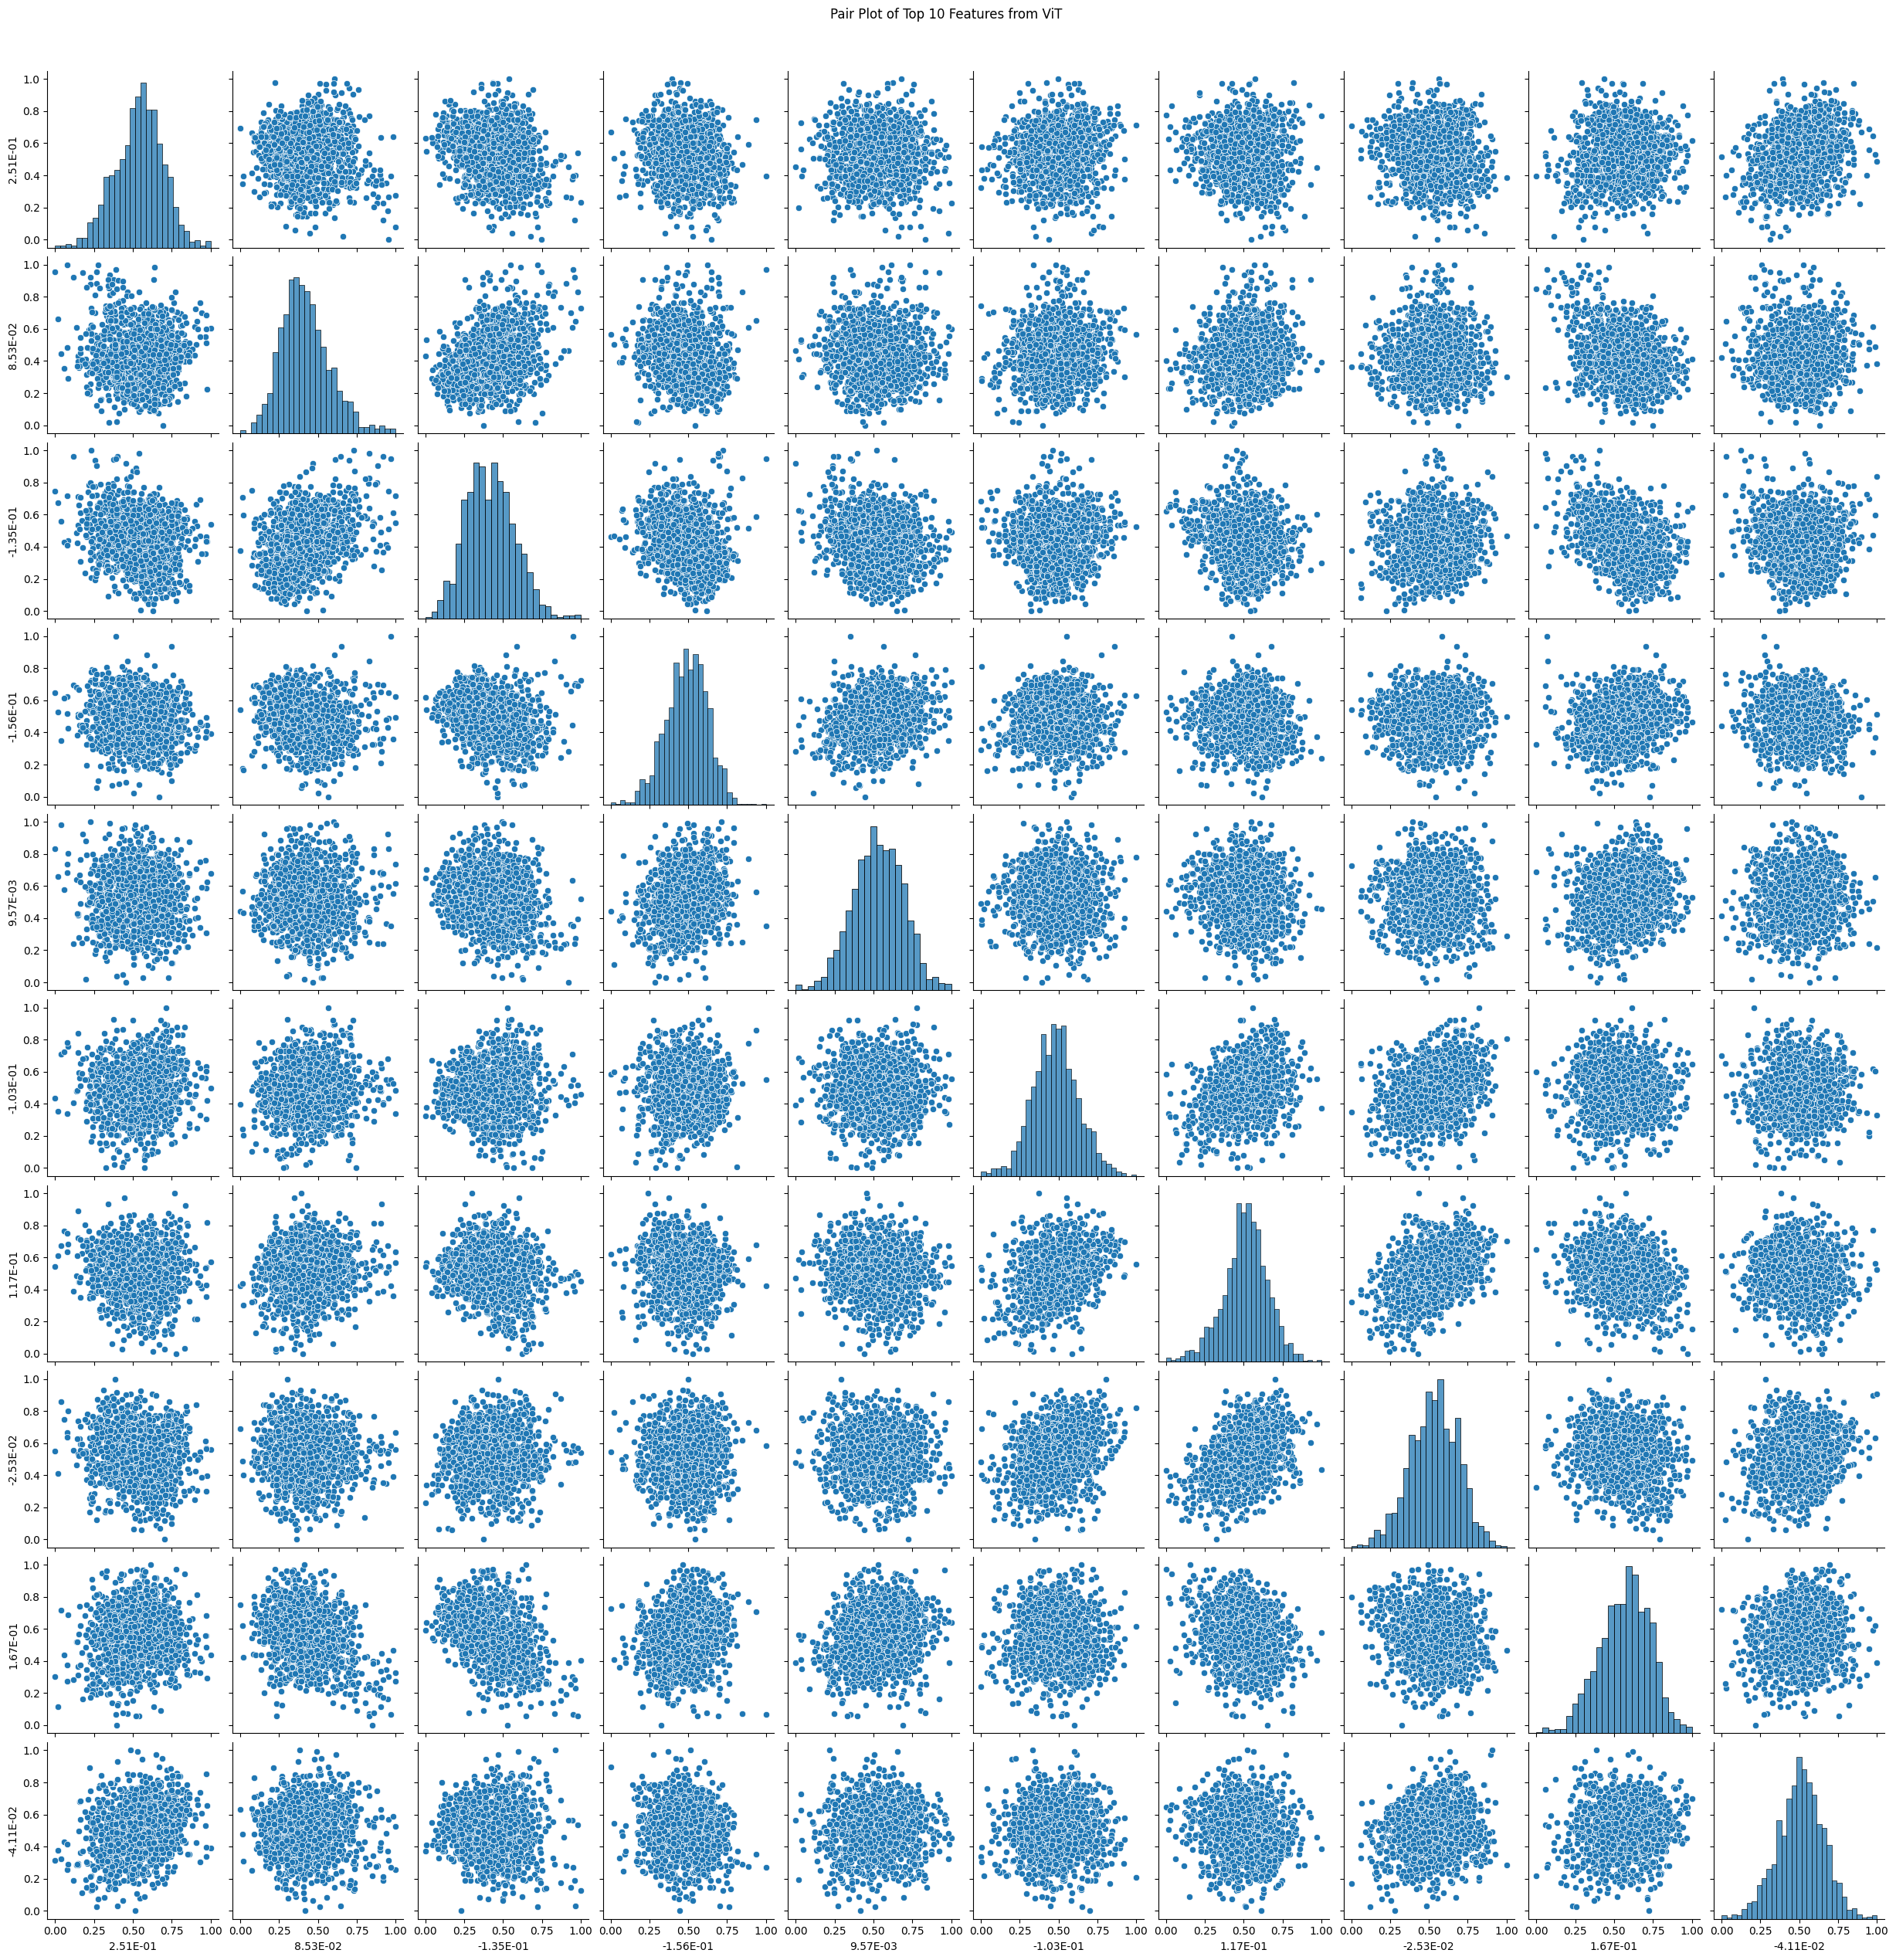

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features
top_10_features = df.iloc[:, :10]  # Adjust the selection if needed

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Plot pair plots
sns.pairplot(top_10_features_normalized, palette='husl')
plt.suptitle('Pair Plot of Top 10 Features from ViT ', y=1.02)
plt.show()


<ipython-input-37-a8f3bc2102f7>:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(top_10_features_normalized[column], label=column, shade=True)
<ipython-input-37-a8f3bc2102f7>:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(top_10_features_normalized[column], label=column, shade=True)
<ipython-input-37-a8f3bc2102f7>:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(top_10_features_normalized[column], label=column, shade=True)
<ipython-input-37-a8f3bc2102f7>:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sn

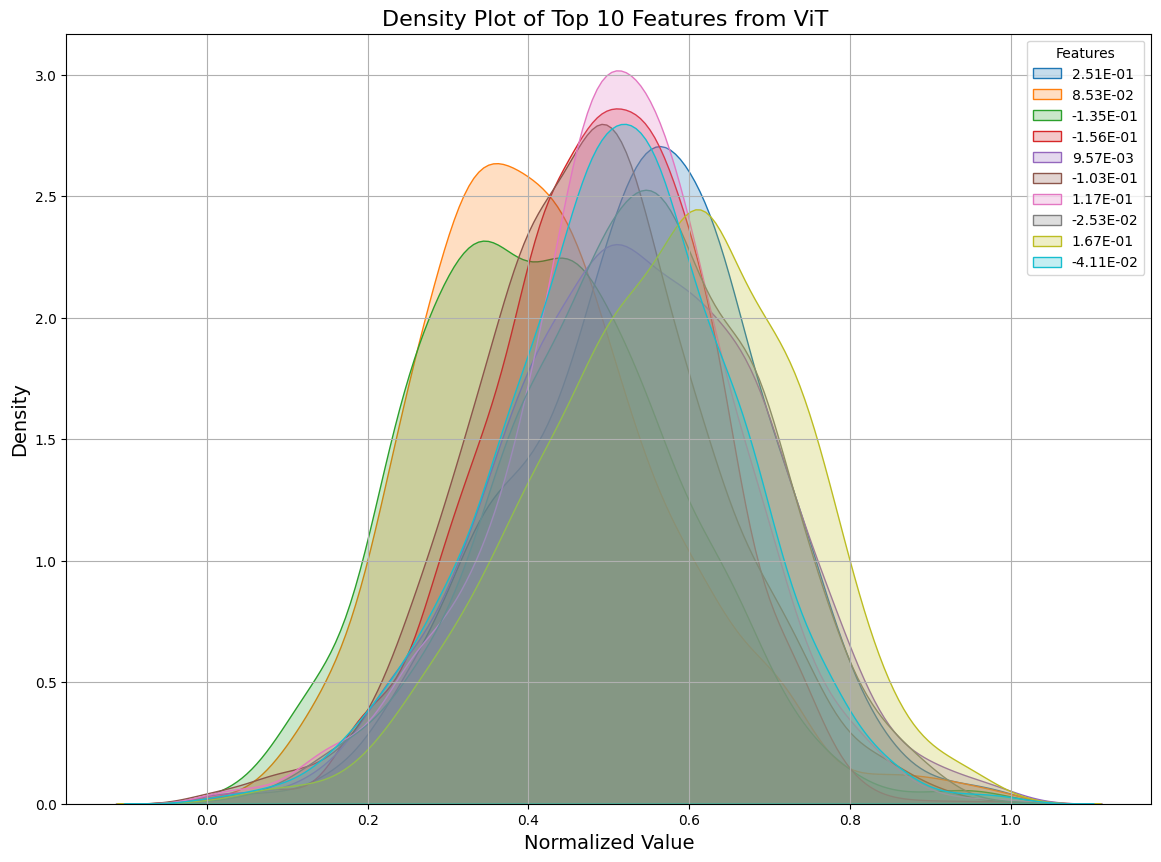

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features
top_10_features = df.iloc[:, :10]  # Adjust the selection if needed

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Plot density plots
plt.figure(figsize=(14, 10))
for column in top_10_features_normalized.columns:
    sns.kdeplot(top_10_features_normalized[column], label=column, shade=True)
plt.title('Density Plot of Top 10 Features from ViT ', fontsize=16)
plt.xlabel('Normalized Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Features')
plt.grid(True)
plt.show()


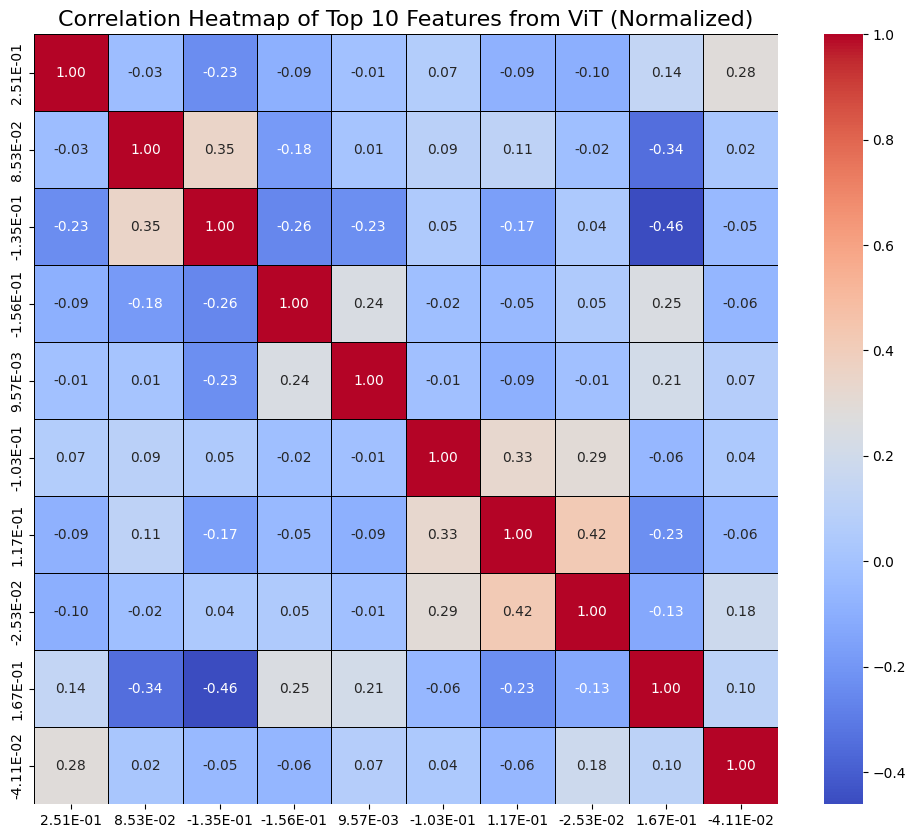

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'   # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features
top_10_features = df.iloc[:, :10]  # Adjust the selection if needed

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Compute the correlation matrix
corr = top_10_features_normalized.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Correlation Heatmap of Top 10 Features from ViT (Normalized)', fontsize=16)
plt.show()


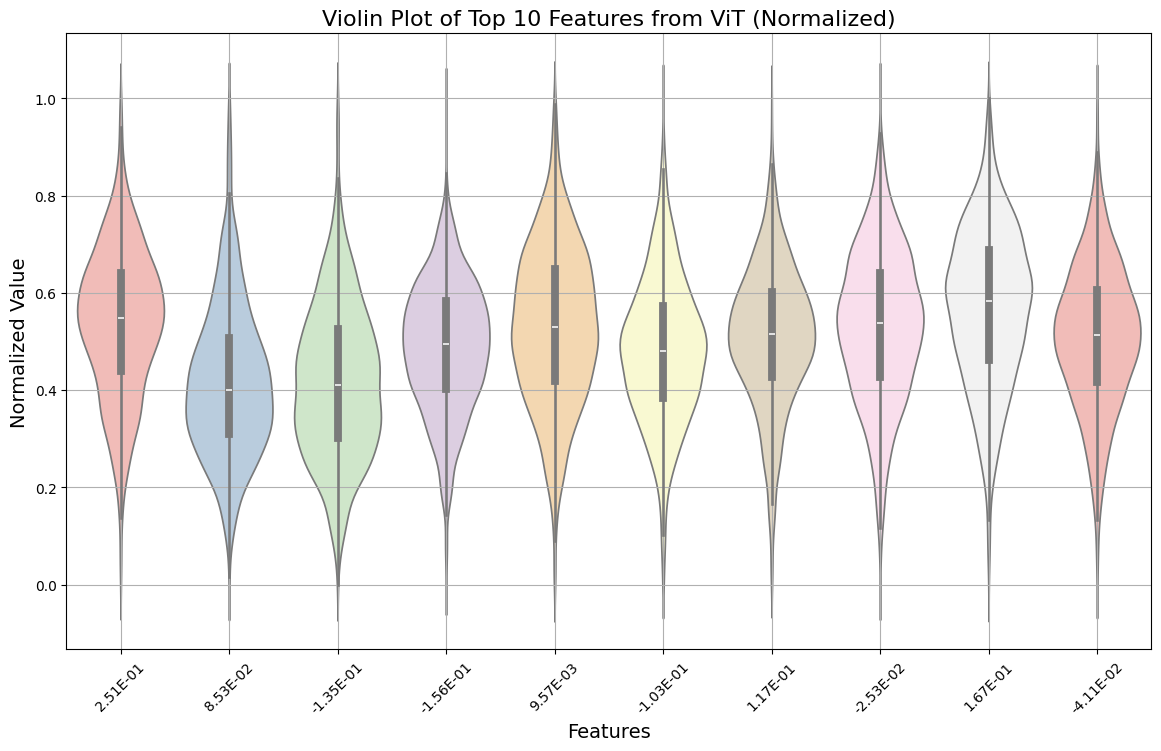

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features
top_10_features = df.iloc[:, :10]  # Adjust the selection if needed

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Plot violin plots
plt.figure(figsize=(14, 8))
sns.violinplot(data=top_10_features_normalized, palette='Pastel1')
plt.title('Violin Plot of Top 10 Features from ViT (Normalized)', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Normalized Value', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


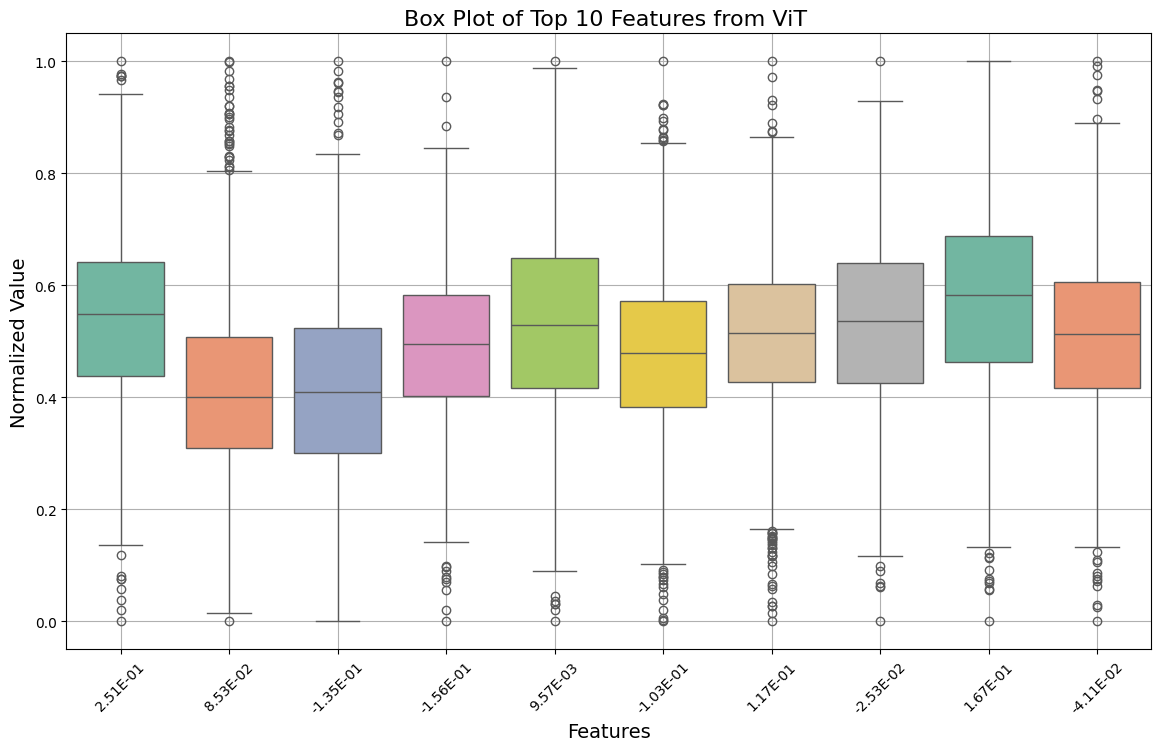

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file into a DataFrame
csv_file_path = '/content/drive/MyDrive/vitfeat.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Select the top 10 features
top_10_features = df.iloc[:, :10]  # Adjust the selection if needed

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
top_10_features_normalized = pd.DataFrame(scaler.fit_transform(top_10_features), columns=top_10_features.columns)

# Plot box plots
plt.figure(figsize=(14, 8))
sns.boxplot(data=top_10_features_normalized, palette='Set2')
plt.title('Box Plot of Top 10 Features from ViT ', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Normalized Value', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
pip install torchviz


  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nv

In [ ]:
import torch
from torchviz import make_dot
from transformers import ViTModel

# Load a pretrained Vision Transformer model
model = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')

# Create a dummy input tensor
dummy_input = torch.randn(1, 3, 224, 224)  # Adjust size if needed

# Forward pass through the model
outputs = model(dummy_input)

# Generate and save a simplified architecture diagram
dot = make_dot(outputs.last_hidden_state, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render(filename='vit_architecture_simplified')


'vit_architecture_simplified.png'

In [ ]:
import torch
from torchviz import make_dot
from transformers import ViTModel

# Load a pretrained Vision Transformer model
model = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')

# Create a dummy input tensor
# Note: Adjust the size of the input tensor to match your model's input size
dummy_input = torch.randn(1, 3, 224, 224)  # Batch size = 1, 3 channels, 224x224 image

# Forward pass through the model to get output
outputs = model(dummy_input)

# Visualize the model architecture
make_dot(outputs.last_hidden_state, params=dict(model.named_parameters())).render('vit_architecture', format='png')


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

'vit_architecture.png'

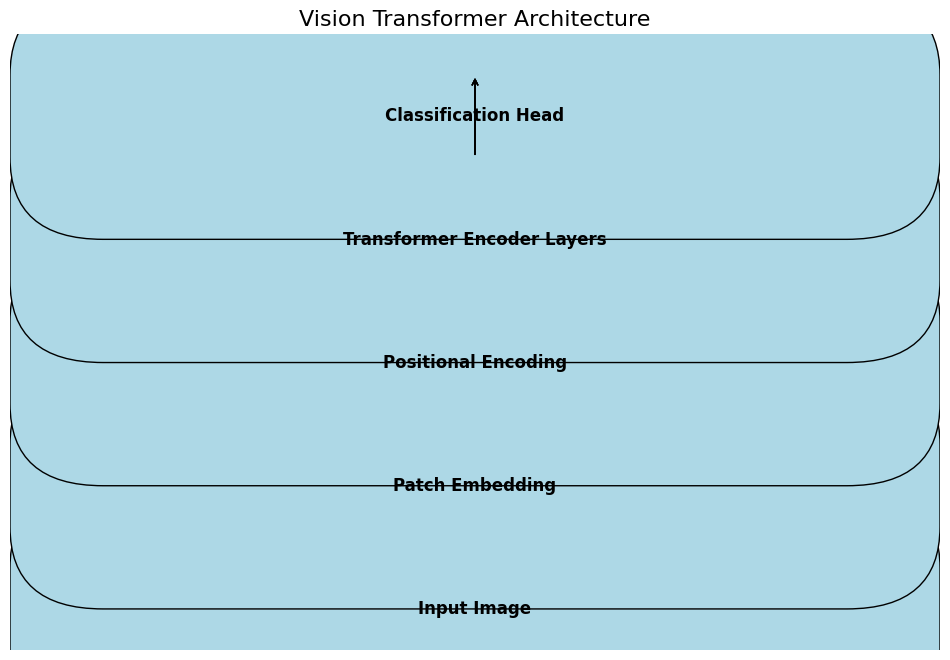

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))

# Draw boxes for each component
components = ['Input Image', 'Patch Embedding', 'Positional Encoding', 'Transformer Encoder Layers', 'Classification Head']
y = 0

for component in components:
    rect = patches.FancyBboxPatch((0.1, y), 0.8, 0.1, boxstyle="round,pad=0.1", edgecolor='black', facecolor='lightblue')
    ax.add_patch(rect)
    ax.text(0.5, y + 0.05, component, ha='center', va='center', fontsize=12, weight='bold')
    y += 0.15

# Add arrows
for i in range(len(components) - 1):
    ax.annotate('', xy=(0.5, y - 0.05), xytext=(0.5, y - 0.15),
                arrowprops=dict(arrowstyle='->', color='black'))

# Set axis limits and remove axes
ax.set_xlim(0, 1)
ax.set_ylim(0, y)
ax.axis('off')

plt.title('Vision Transformer Architecture', fontsize=16)
plt.show()


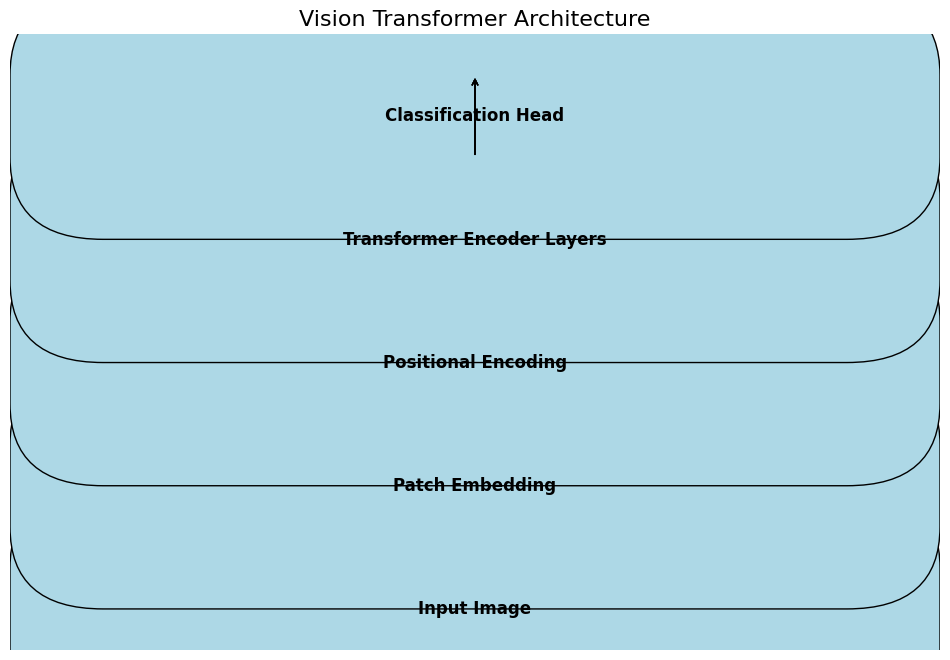

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))

# Draw boxes for each component
components = ['Input Image', 'Patch Embedding', 'Positional Encoding', 'Transformer Encoder Layers', 'Classification Head']
y = 0

for component in components:
    rect = patches.FancyBboxPatch((0.1, y), 0.8, 0.1, boxstyle="round,pad=0.1", edgecolor='black', facecolor='lightblue')
    ax.add_patch(rect)
    ax.text(0.5, y + 0.05, component, ha='center', va='center', fontsize=12, weight='bold')
    y += 0.15

# Add arrows
for i in range(len(components) - 1):
    ax.annotate('', xy=(0.5, y - 0.05), xytext=(0.5, y - 0.15),
                arrowprops=dict(arrowstyle='->', color='black'))

# Set axis limits and remove axes
ax.set_xlim(0, 1)
ax.set_ylim(0, y)
ax.axis('off')

plt.title('Vision Transformer Architecture', fontsize=16)
plt.show()


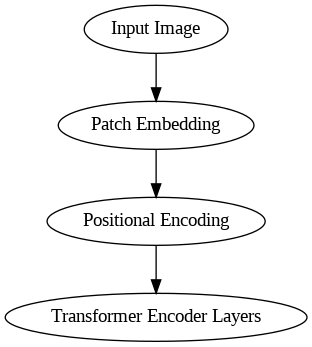

In [ ]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph()

# Add nodes with labels
dot.node('A', 'Input Image')
dot.node('B', 'Patch Embedding')
dot.node('C', 'Positional Encoding')
dot.node('D', 'Transformer Encoder Layers')

# Add edges to represent data flow
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')

# Render the graph to a file
dot.render('vit_architecture_simple', format='png', cleanup=True)

# Display the graph
from IPython.display import Image
Image('vit_architecture_simple.png')


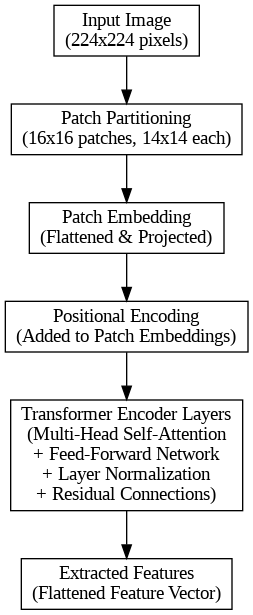

In [ ]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph('ViT', comment='Vision Transformer - Feature Extraction Architecture')

# Input Image
dot.node('InputImage', 'Input Image\n(224x224 pixels)', shape='rect')

# Patch Partitioning
dot.node('PatchPartition', 'Patch Partitioning\n(16x16 patches, 14x14 each)', shape='rect')

# Patch Embedding
dot.node('PatchEmbedding', 'Patch Embedding\n(Flattened & Projected)', shape='rect')

# Positional Encoding
dot.node('PositionalEncoding', 'Positional Encoding\n(Added to Patch Embeddings)', shape='rect')

# Transformer Encoder Layers
dot.node('TransformerEncoders', 'Transformer Encoder Layers\n(Multi-Head Self-Attention\n+ Feed-Forward Network\n+ Layer Normalization\n+ Residual Connections)', shape='rect')

# Output Feature Vector
dot.node('OutputFeatures', 'Extracted Features\n(Flattened Feature Vector)', shape='rect')

# Connecting Nodes
dot.edge('InputImage', 'PatchPartition')
dot.edge('PatchPartition', 'PatchEmbedding')
dot.edge('PatchEmbedding', 'PositionalEncoding')
dot.edge('PositionalEncoding', 'TransformerEncoders')
dot.edge('TransformerEncoders', 'OutputFeatures')

# Render the graph to a file
dot.render('vit_architecture_detailed', format='png', cleanup=True)

# Display the graph
from IPython.display import Image
Image('vit_architecture_detailed.png')


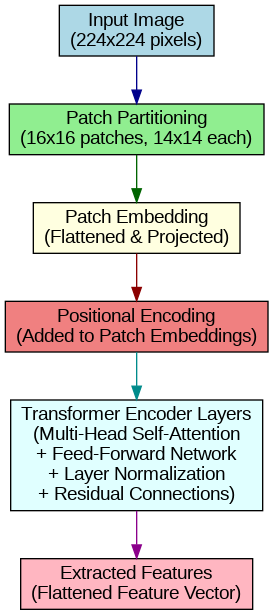

In [ ]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph('ViT', comment='Vision Transformer - Feature Extraction Architecture')

# Define node attributes (color, style, etc.)
node_attrs = {
    'shape': 'rect',
    'style': 'filled',
    'fontname': 'Helvetica'
}

# Input Image (colored light blue)
dot.node('InputImage', 'Input Image\n(224x224 pixels)', **node_attrs, fillcolor='lightblue')

# Patch Partitioning (colored light green)
dot.node('PatchPartition', 'Patch Partitioning\n(16x16 patches, 14x14 each)', **node_attrs, fillcolor='lightgreen')

# Patch Embedding (colored light yellow)
dot.node('PatchEmbedding', 'Patch Embedding\n(Flattened & Projected)', **node_attrs, fillcolor='lightyellow')

# Positional Encoding (colored light coral)
dot.node('PositionalEncoding', 'Positional Encoding\n(Added to Patch Embeddings)', **node_attrs, fillcolor='lightcoral')

# Transformer Encoder Layers (colored light cyan)
dot.node('TransformerEncoders', 'Transformer Encoder Layers\n(Multi-Head Self-Attention\n+ Feed-Forward Network\n+ Layer Normalization\n+ Residual Connections)', **node_attrs, fillcolor='lightcyan')

# Output Feature Vector (colored light pink)
dot.node('OutputFeatures', 'Extracted Features\n(Flattened Feature Vector)', **node_attrs, fillcolor='lightpink')

# Connecting Nodes (colored dark blue)
dot.edge('InputImage', 'PatchPartition', color='darkblue')
dot.edge('PatchPartition', 'PatchEmbedding', color='darkgreen')
dot.edge('PatchEmbedding', 'PositionalEncoding', color='darkred')
dot.edge('PositionalEncoding', 'TransformerEncoders', color='darkcyan')
dot.edge('TransformerEncoders', 'OutputFeatures', color='darkmagenta')

# Render the graph to a file
dot.render('vit_architecture_colored', format='png', cleanup=True)

# Display the graph
from IPython.display import Image
Image('vit_architecture_colored.png')


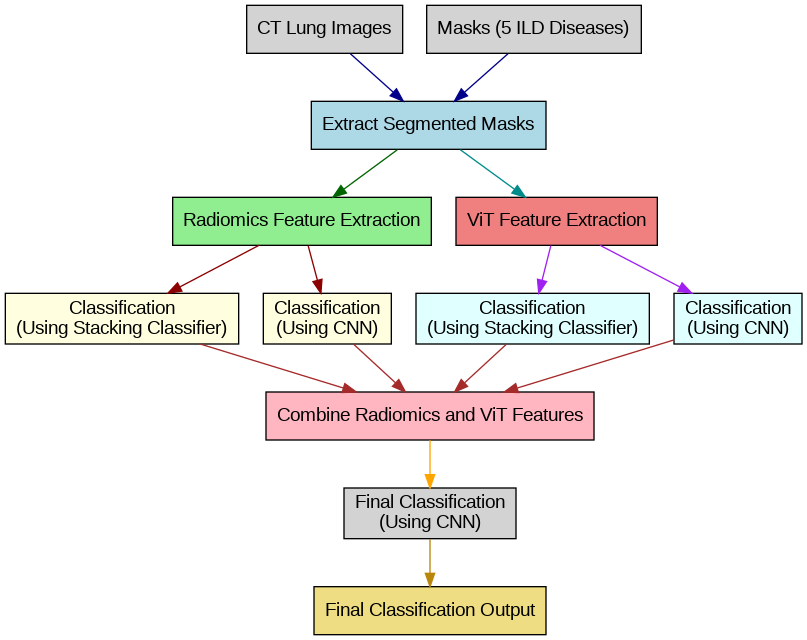

In [ ]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph('Workflow', comment='Complete Workflow Diagram')

# Define node attributes (color, style, etc.)
node_attrs = {
    'shape': 'rect',
    'style': 'filled',
    'fontname': 'Helvetica',
    'fillcolor': 'lightgray'  # Default fillcolor
}

# Input Nodes
dot.node('InputCT', 'CT Lung Images', **node_attrs)
dot.node('InputMasks', 'Masks (5 ILD Diseases)', **node_attrs)

# Segmentation
dot.node('Segmentation', 'Extract Segmented Masks',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightblue')

# Radiomics Feature Extraction
dot.node('RadiomicsExtraction', 'Radiomics Feature Extraction',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightgreen')

# Classification with Radiomics
dot.node('RadiomicsStacking', 'Classification\n(Using Stacking Classifier)',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightyellow')
dot.node('RadiomicsCNN', 'Classification\n(Using CNN)',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightyellow')

# Vision Transformer (ViT) Feature Extraction
dot.node('ViTExtraction', 'ViT Feature Extraction',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightcoral')

# Classification with ViT
dot.node('ViTStacking', 'Classification\n(Using Stacking Classifier)',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightcyan')
dot.node('ViTCNN', 'Classification\n(Using CNN)',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightcyan')

# Combined Features
dot.node('CombinedFeatures', 'Combine Radiomics and ViT Features',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightpink')

# Final Classification
dot.node('FinalCNN', 'Final Classification\n(Using CNN)',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightgray')

# Results
dot.node('Results', 'Final Classification Output',
         shape='rect', style='filled', fontname='Helvetica', fillcolor='lightgoldenrod')

# Connecting Nodes
dot.edge('InputCT', 'Segmentation', color='darkblue')
dot.edge('InputMasks', 'Segmentation', color='darkblue')

dot.edge('Segmentation', 'RadiomicsExtraction', color='darkgreen')
dot.edge('RadiomicsExtraction', 'RadiomicsStacking', color='darkred')
dot.edge('RadiomicsExtraction', 'RadiomicsCNN', color='darkred')

dot.edge('Segmentation', 'ViTExtraction', color='darkcyan')
dot.edge('ViTExtraction', 'ViTStacking', color='purple')
dot.edge('ViTExtraction', 'ViTCNN', color='purple')

dot.edge('RadiomicsStacking', 'CombinedFeatures', color='brown')
dot.edge('RadiomicsCNN', 'CombinedFeatures', color='brown')
dot.edge('ViTStacking', 'CombinedFeatures', color='brown')
dot.edge('ViTCNN', 'CombinedFeatures', color='brown')

dot.edge('CombinedFeatures', 'FinalCNN', color='orange')
dot.edge('FinalCNN', 'Results', color='darkgoldenrod')

# Render the graph to a file
dot.render('complete_workflow_diagram_colored', format='png', cleanup=True)

# Display the graph
from IPython.display import Image
Image('complete_workflow_diagram_colored.png')

